# Making conditional graphs

adding router nodes

In [1]:
from dataclasses import dataclass
from langgraph.graph import StateGraph, START, END

In [2]:
@dataclass
class AgentState:
    num1 : int = 0
    num2: int = 0
    ops1: str = "+"
    
    ops2: str = "-"
    num3: int = 0
    num4: int = 0
    finalNum: int = 0
    finalNum2: int = 0

In [3]:
def add(state: AgentState)-> AgentState:
    """This node adds inputs"""
    state.finalNum = state.num1 + state.num2
    return state

def sub(state: AgentState)-> AgentState:
    """This node sub inputs"""
    state.finalNum = state.num1 - state.num2    
    return state

def add2(state: AgentState)-> AgentState:
    """This node adds inputs"""
    state.finalNum2 = state.num3 + state.num4
    return state

def sub2(state: AgentState)-> AgentState:
    """This node sub inputs"""
    state.finalNum2 = state.num3 - state.num4    
    return state
    


def decider(state: AgentState)-> str:
    """This node makes a decision """
    if state.ops1 == "+":
        return "add_edge"
    elif state.ops1 == "-":
        return "sub_edge"


def decider2(state: AgentState)-> str:
    """This node makes a decision """
    if state.ops2 == "+":
        return "add_edge2"
    elif state.ops2 == "-":
        return "sub_edge2"

In [4]:
graph = StateGraph(AgentState)

graph.add_node("add_node",add)
graph.add_node("sub_node",sub)
graph.add_node("add_node2",add2)
graph.add_node("sub_node2",sub2)
graph.add_node("router",lambda state:state)
graph.add_node("router2",lambda state:state)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router", decider,
    {
        # Edge:Node
        "add_edge":"add_node",
        "sub_edge":"sub_node"
    }
)

graph.add_edge("add_node","router2")
graph.add_edge("sub_node", "router2")


graph.add_conditional_edges(
    "router2", decider2,
    {
        # Edge:Node
        "add_edge2":"add_node2",
        "sub_edge2":"sub_node2"
    }
)



graph.add_edge("add_node2",END)
graph.add_edge("sub_node2",END)

app = graph.compile()

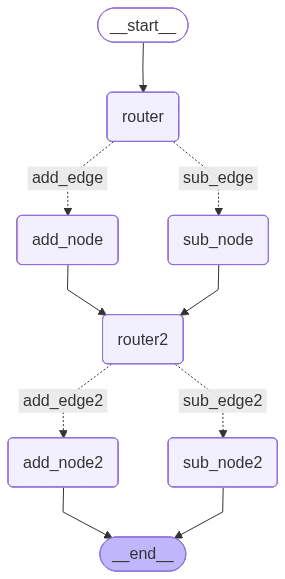

In [5]:
from IPython.display import Image,display 
display(Image(app.get_graph().draw_mermaid_png()))


In [6]:
print(app.invoke({"num1":2,"ops1":"-","num2":11,"ops2":"+","num3":3,"num4":8}))

{'num1': 2, 'num2': 11, 'ops1': '-', 'ops2': '+', 'num3': 3, 'num4': 8, 'finalNum': -9, 'finalNum2': 11}
